# Spatial Copper Mining in DR Congo
# ii. Mining Core Analysis

This notebook builds directly on the layers loaded in `i.spatial_foundation`. It covers:

- Reprojection and CRS standardisation
- Buffers and influence zones
- Spatial join and dissolve
- Kernel Density Estimation (KDE) of mineral occurrences
- Spatial clustering with DBSCAN
- Spatial autocorrelation with Moran's I
- Distance analysis (mines → roads, rivers, borders)


### Set up

In [35]:
import sys
import warnings
from pathlib import Path

import geopandas as gpd
import numpy as np
import rioxarray as rxr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import box
from adjustText import adjust_text
from matplotlib.colors import LightSource
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from esda.moran import Moran
from libpysal.weights import Queen

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from obtain_remote_data import (
    COPPERBELT_BBOX,
    CRS_PROJ,
    CRS_GEO,
    PROJECT_ROOT,
    DATA_RAW,
    DATA_PROCESSED,
    MAPS_OUT,
    FIGURES_OUT,
    load_full_copperbelt_admin,
    load_mrds,
    load_overture_data,
    load_srtm,
)

MAPS_OUT = MAPS_OUT / "mining_core"
FIGURES_OUT = FIGURES_OUT / "mining_core"

for _d in (DATA_RAW, DATA_PROCESSED, MAPS_OUT, FIGURES_OUT):
    _d.mkdir(parents=True, exist_ok=True)


### Load raw data

In [2]:
infrastructure = gpd.read_parquet(DATA_RAW / "copperbelt_infrastructure.parquet")
infrastructure = infrastructure.cx[
    COPPERBELT_BBOX[0]:COPPERBELT_BBOX[2],
    COPPERBELT_BBOX[1]:COPPERBELT_BBOX[3],
]

roads  = load_overture_data(COPPERBELT_BBOX, layer_type="segment")
water  = load_overture_data(COPPERBELT_BBOX, layer_type="water")
districts = load_full_copperbelt_admin(COPPERBELT_BBOX, level=2)
mrds   = load_mrds(COPPERBELT_BBOX)

srtm_path = DATA_RAW / "srtm_copperbelt.tif"
if srtm_path.exists():
    dem = rxr.open_rasterio(srtm_path).squeeze()
else:
    dem = load_srtm(COPPERBELT_BBOX, output_path=srtm_path)

# Derived layers
countries = districts.dissolve(by="GID_0")
rdc    = countries.loc[["COD"]].geometry.values[0]
zambia = countries.loc[["ZMB"]].geometry.values[0]
boundary = rdc.intersection(zambia)

mrds["ore_simple"] = mrds["ore"].str.split(",").str[:2].str.join(", ").fillna("Not specified")
top_5 = mrds["ore_simple"].value_counts().nlargest(5).index
mrds["ore_map"] = mrds["ore_simple"].apply(lambda x: x if x in top_5 else "Others")

ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem.values, vert_exag=0.6)

  Overture 'segment' — 4,003 features loaded.
  Overture 'water' — 14,152 features loaded.
  GADM — downloading COD level 2...
    COD: 13 units loaded.
  GADM — downloading ZMB level 2...
    ZMB: 31 units loaded.
  MRDS — reading local cache: mrds_copperbelt.parquet


## 2.1 Reprojection and CRS standardisation

All vector layers arrive in **EPSG:4326** (geographic, degrees).
Distance-based operations (buffers, KDE, DBSCAN) require a **projected CRS in metres**.<br> 

Using **EPSG:32735** (UTM zone 35S), which covers the Copperbelt region.<br>

Key concepts:
- `to_crs()` reprojects any GeoDataFrame
- The CRS must be consistent across all layers before any spatial operation
- The original WGS84 layers are kept for plotting; projected layers are used only for analysis

In [9]:
mrds_utm      = mrds.to_crs(CRS_PROJ)
districts_utm = districts.to_crs(CRS_PROJ)
countries_utm = countries.to_crs(CRS_PROJ)
roads_utm     = roads.to_crs(CRS_PROJ)
water_utm     = water.to_crs(CRS_PROJ)
infra_utm     = infrastructure.to_crs(CRS_PROJ)

bbox_poly = gpd.GeoSeries([box(*COPPERBELT_BBOX)], crs=CRS_GEO).to_crs(CRS_PROJ)
#print(bbox_poly.total_bounds)
xmin, ymin, xmax, ymax = [190000, 8460000, 800000, 8890000]  # manually adjusted to better fit the study area and exclude outliers

print("CRS check:")
print(f"  mrds_utm      → {mrds_utm.crs}")
print(f"  districts_utm → {districts_utm.crs}")
print(f"  roads_utm     → {roads_utm.crs}")
print(f"\nBbox in metres (approx):")
b = districts_utm.total_bounds
print(f"  Width : {(b[2]-b[0])/1000:.0f} km")
print(f"  Height: {(b[3]-b[1])/1000:.0f} km")

# Study area polygon — used to mask the KDE surface (section 2.4)
study_area = districts_utm.union_all()

CRS check:
  mrds_utm      → EPSG:32735
  districts_utm → EPSG:32735
  roads_utm     → EPSG:32735

Bbox in metres (approx):
  Width : 863 km
  Height: 846 km


## 2.2 Buffers and influence zones

Buffers quantify proximity — a fundamental concept in mineral prospectivity. I generated three types:

- **Mine influence zones**: 25 km radius around each MRDS occurrence
- **Road access corridors**: 10 km around primary/motorway roads
- **Dissolved mine buffer**: union of all mine buffers to show total coverage

In [12]:
# --- Mine influence zones (15 km)
MINE_BUFFER_KM = 10_000   # metres

mine_buffers = mrds_utm.copy()
mine_buffers["geometry"] = mrds_utm.buffer(MINE_BUFFER_KM)

# Dissolved version: single polygon showing total mine influence
mine_buffer_dissolved = mine_buffers.dissolve()

# --- Road access corridors (5 km, primary roads only)
ROAD_BUFFER_KM = 5_000

road_buffers = roads_utm.copy()
road_buffers["geometry"] = roads_utm.buffer(ROAD_BUFFER_KM)
road_buffer_dissolved = road_buffers.dissolve()

# --- Area covered by mine influence (km²)
mine_coverage_km2 = mine_buffer_dissolved.geometry.area.sum() / 1e6
print(f"Total mine influence area (25 km buffer, dissolved): {mine_coverage_km2:,.0f} km²")
print(f"Total study area: {study_area.area/1e6:,.0f} km²")
print(f"Coverage ratio: {mine_coverage_km2 / (study_area.area/1e6):.1%}")


Total mine influence area (25 km buffer, dissolved): 20,496 km²
Total study area: 409,269 km²
Coverage ratio: 5.0%


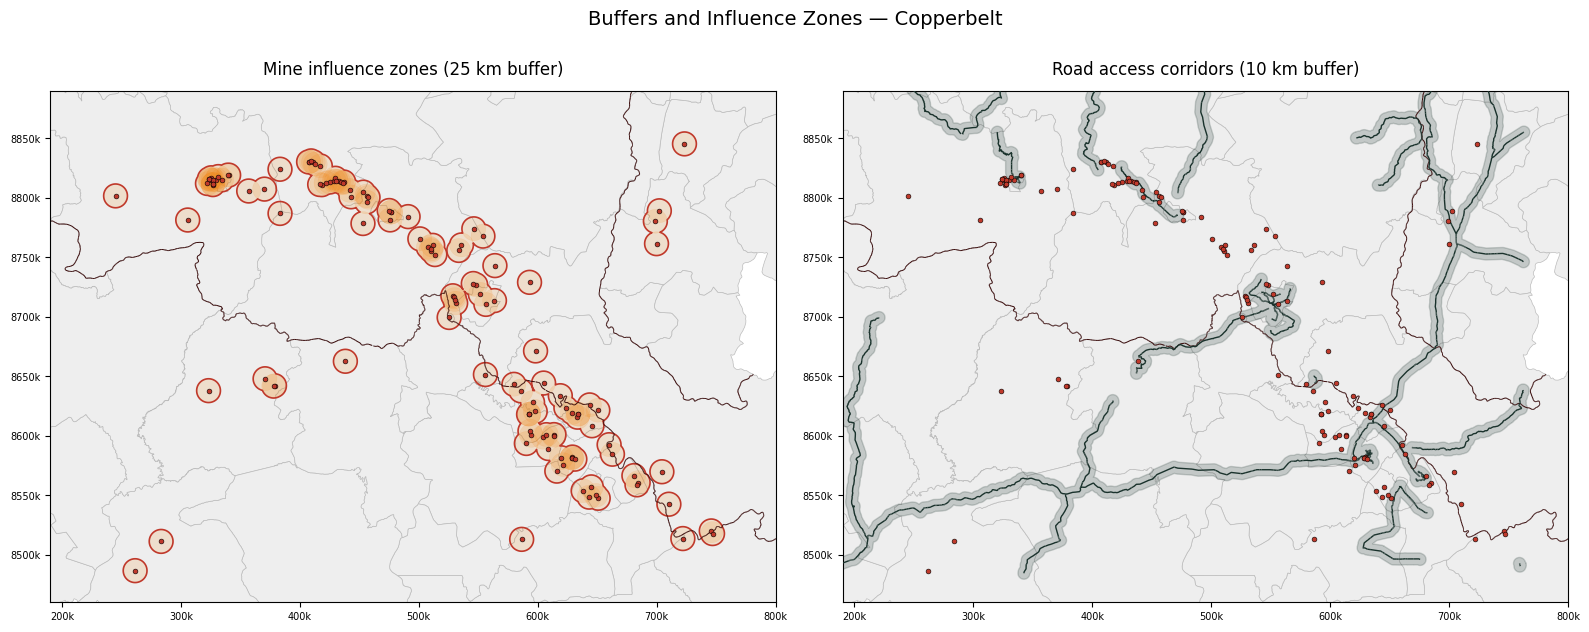

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax in axes:
    districts_utm.plot(ax=ax, color="#eeeeee", edgecolor="#bcbcbc", linewidth=0.5)
    gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(CRS_PROJ).plot(
        ax=ax, color="#3B0B0B", linewidth=0.7, linestyle="--"
    )

# Left: mine influence zones
mine_buffers.plot(
    ax=axes[0], color="#f1840f", alpha=0.15, edgecolor="#f1840f", linewidth=0.3
)
mine_buffer_dissolved.plot(
    ax=axes[0], color="none", edgecolor="#c0392b", linewidth=1.2, linestyle="-"
)
mrds_utm.plot(
    ax=axes[0], color="#c0392b", markersize=12, edgecolor="black", linewidth=0.4, zorder=5
)
axes[0].set_title("Mine influence zones (25 km buffer)", fontsize=12, pad=12)

# Right: road access corridors
road_buffer_dissolved.plot(
    ax=axes[1], color="#1A322C", alpha=0.2, edgecolor="#1A322C", linewidth=1
)
roads_utm.plot(ax=axes[1], color="#1A322C", linewidth=1, zorder=4)
mrds_utm.plot(
    ax=axes[1], color="#c0392b", markersize=12, edgecolor="black", linewidth=0.4, zorder=5,
    label="Mine locations"
)
axes[1].set_title("Road access corridors (10 km buffer)", fontsize=12, pad=12)

for ax in axes:
    ax.axis("on")
    ax.tick_params(labelsize=7)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    # Format axis labels as km
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

plt.suptitle("Buffers and Influence Zones — Copperbelt", fontsize=14, y=0.9)
plt.tight_layout()
plt.savefig(MAPS_OUT / "buffers.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.3 Spatial join and dissolve

A **spatial join** attaches attributes from one layer to features in another based on their geometric relationship (intersects, within, nearest).<br>

Here each mine point is joined to the district it falls in, then **dissolve** districts by country to count mines per administrative unit.


In [14]:
# --- Spatial join: mine → district
mrds_with_district = gpd.sjoin(
    mrds_utm,
    districts_utm[["GID_0", "GID_2", "NAME_2", "geometry"]],
    how="left",
    predicate="within",
)

print("Mines per district (top 10):")
print(
    mrds_with_district.groupby("NAME_2")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .to_string()
)

Mines per district (top 10):
NAME_2
Lubudi        20
Kambove       16
Mutshatsha    13
Sakania        9
Kipushi        8
Kitwe          6
Mufulira       6
Kalulushi      6
Chingola       5
Luanshya       5


In [15]:
# --- Dissolve: aggregate mine count to district level
mine_counts = (
    mrds_with_district.groupby("NAME_2")
    .size()
    .reset_index(name="mine_count")
)

districts_counts = districts_utm.merge(mine_counts, on="NAME_2", how="left")
districts_counts["mine_count"] = districts_counts["mine_count"].fillna(0).astype(int)


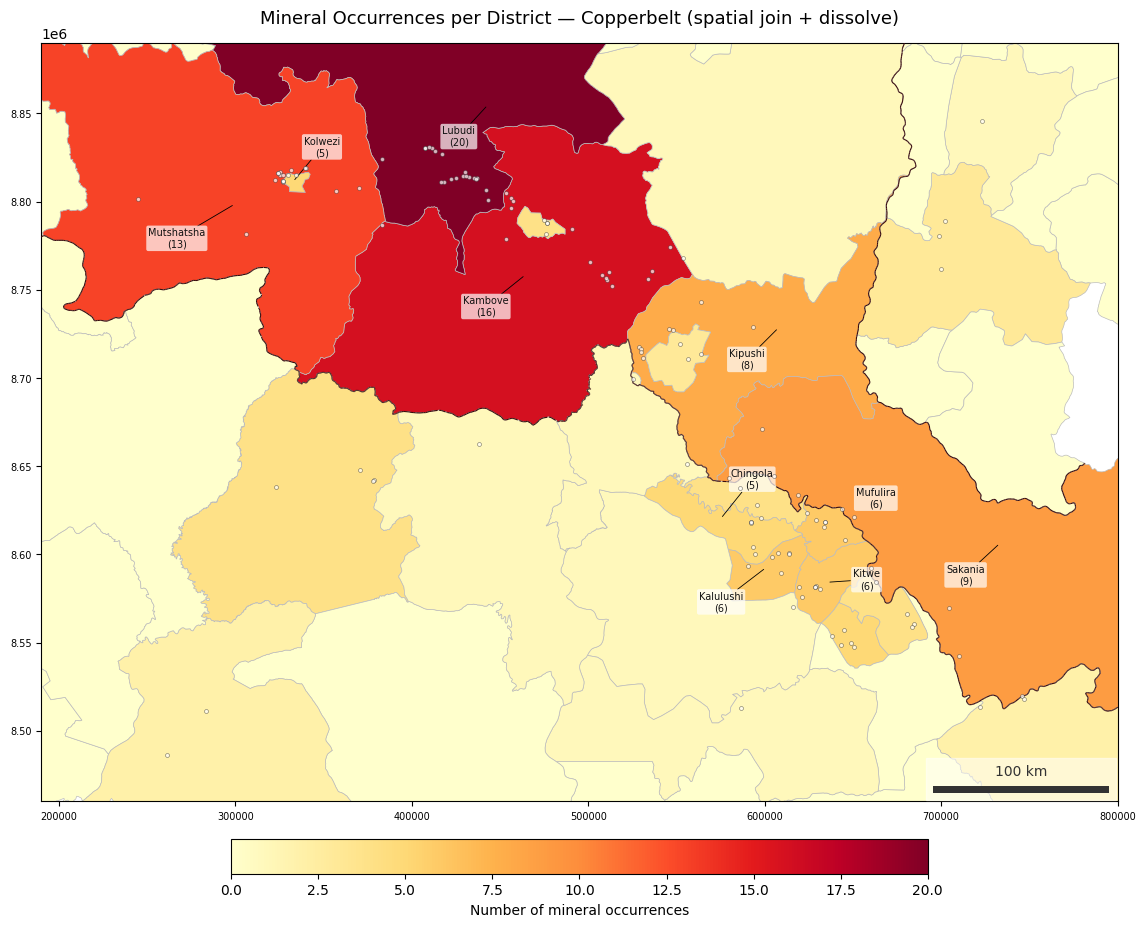

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))

districts_counts.plot(
    ax=ax,
    column="mine_count",
    cmap="YlOrRd",
    edgecolor="#bcbcbc",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "label": "Number of mineral occurrences",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.04,
    },
)

gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(CRS_PROJ).plot(
    ax=ax, color="#3B0B0B", linewidth=0.8, linestyle="--", zorder=3
)

mrds_utm.plot(
    ax=ax, color="white", markersize=8, edgecolor="#333", linewidth=0.4,
    alpha=0.7, zorder=4, label="Mine locations"
)

# District labels for top-10 mine districts
texts = []
for _, row in districts_counts.nlargest(10, "mine_count").iterrows():
    x, y = row.geometry.representative_point().coords[0]
    txt = ax.text(
        x, y,
        f"{row['NAME_2']}\n({row['mine_count']})",
        fontsize=7, ha="center", va="center", color="#111",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none")
    )
    texts.append(txt)

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="black", lw=0.6)
)

ax.set_title("Mineral Occurrences per District — Copperbelt (spatial join + dissolve)",
             fontsize=13, pad=14)
ax.axis("on")
ax.tick_params(labelsize=7)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

scalebar = ScaleBar(1, units="m", dimension="si-length", location="lower right",
                    fixed_value=100, fixed_units="km", frameon=True, color="#333333",
                    box_alpha=0.5, pad=0.5, scale_loc="top")
ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig(MAPS_OUT / "spatial_join_districts.png", dpi=300)
plt.show()

# Save enriched layer for downstream notebooks
districts_counts.to_file(DATA_PROCESSED / "districts_mine_counts.gpkg", driver="GPKG")


## 2.4 Kernel Density Estimation (KDE)

KDE estimates a smooth **mineralisation density surface** from point occurrences.<br>

Dense clusters of mines produce high-density peaks; isolated occurrences create broad, low shoulders. The bandwidth controls how much each point "spreads".<br>

Using `scipy.stats.gaussian_kde` on the UTM coordinates.

In [23]:
# Extract projected coordinates
coords = np.vstack([mrds_utm.geometry.x, mrds_utm.geometry.y])

# Build KDE on a regular grid covering the study area
b = districts_utm.total_bounds           # [xmin, ymin, xmax, ymax]
GRID_CELLS = 300                          # resolution: ~1 km cells at this scale

xi = np.linspace(b[0], b[2], GRID_CELLS)
yi = np.linspace(b[1], b[3], GRID_CELLS)
xx, yy = np.meshgrid(xi, yi)
grid_points = np.vstack([xx.ravel(), yy.ravel()])

# Bandwidth in metres (Scott's rule ≈ 50 km at this data density; we set explicit 40 km)
bw = 40_000   # metres — tune this to taste

kde = gaussian_kde(coords, bw_method=bw / coords.std(axis=1).mean())
zz = kde(grid_points).reshape(xx.shape)

# Mask cells outside the study area polygon using a simple rasterisation approach
from shapely.vectorized import contains  # noqa: E402
mask = contains(study_area, xx.ravel(), yy.ravel()).reshape(xx.shape)
zz_masked = np.where(mask, zz, np.nan)


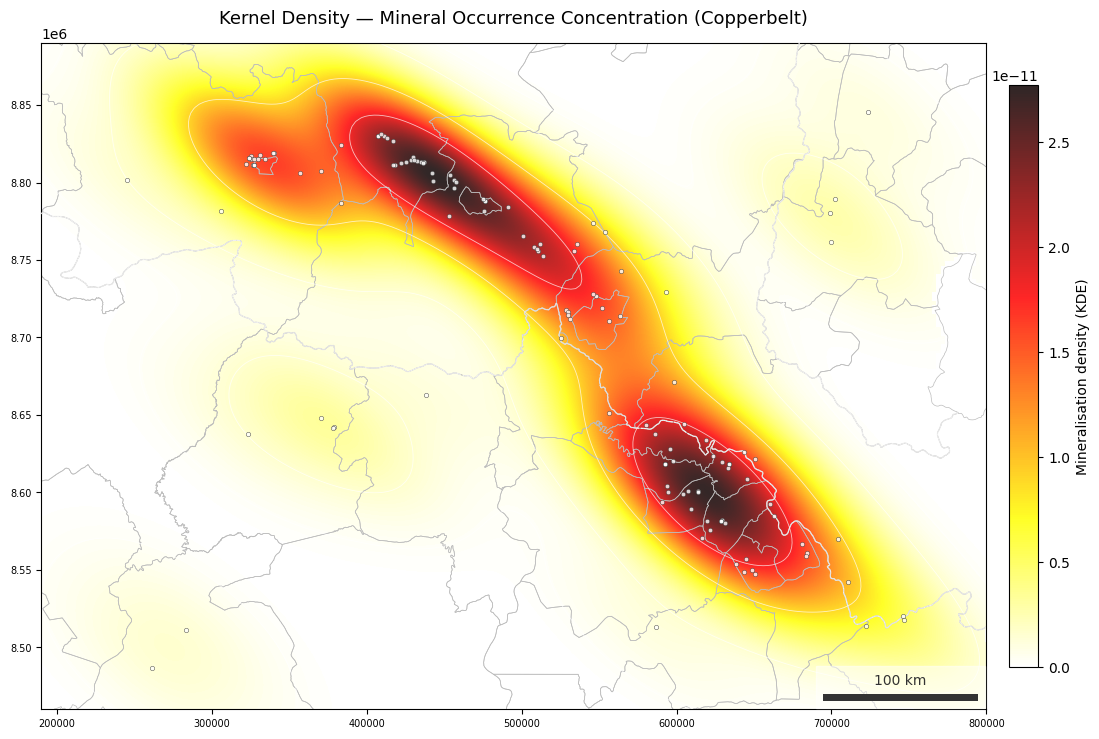

In [24]:
fig, ax = plt.subplots(figsize=(12, 10))

# KDE surface
im = ax.imshow(
    zz_masked,
    origin="lower",
    extent=[b[0], b[2], b[1], b[3]],
    cmap="hot_r",
    alpha=0.85,
    interpolation="bilinear",
)

plt.colorbar(im, ax=ax, label="Mineralisation density (KDE)", shrink=0.6, pad=0.02)

# KDE contours
levels = np.nanpercentile(zz_masked[~np.isnan(zz_masked)], [50, 75, 90, 97])
ax.contour(xx, yy, zz_masked, levels=levels, colors="white", linewidths=0.6, alpha=0.7)

# District outlines
districts_utm.plot(ax=ax, color="none", edgecolor="#bcbcbc", linewidth=0.5)

# Border
gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(CRS_PROJ).plot(
    ax=ax, color="#f0f0f0", linewidth=0.9, linestyle="--", zorder=3
)

# Mine points
mrds_utm.plot(
    ax=ax, color="white", markersize=10, edgecolor="#333", linewidth=0.4, alpha=0.8, zorder=5
)

ax.set_title("Kernel Density — Mineral Occurrence Concentration (Copperbelt)",
             fontsize=13, pad=14)
ax.axis("on")
ax.tick_params(labelsize=7)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

scalebar = ScaleBar(1, units="m", dimension="si-length", location="lower right",
                    fixed_value=100, fixed_units="km", frameon=True, color="#333333",
                    box_alpha=0.5, pad=0.5, scale_loc="top")
ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig(MAPS_OUT / "kde_mineralisation.png", dpi=300)
plt.show()

## 2.5 Spatial clustering with DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise)
groups points that are close together in space, without requiring a
pre-defined number of clusters. Points that don't belong to any cluster
are labelled as **noise** (label = -1).<br>

Key parameters:

- `eps`: neighbourhood radius in metres (using `NearestNeighbors` to find out the optimum value)
- `min_samples`: minimum points to form a cluster core

This reveals **mining districts** — concentrations of co-located occurrences.

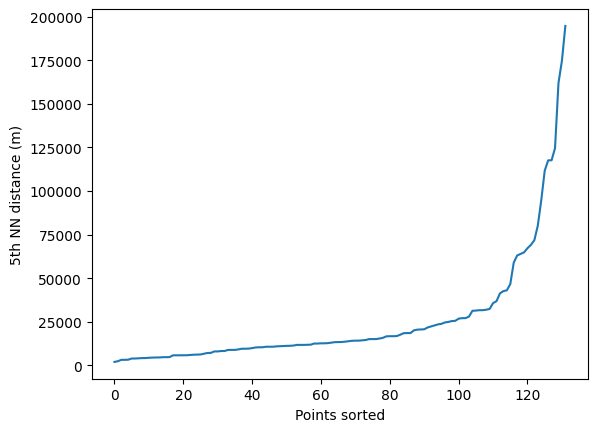

In [25]:
X = np.column_stack([mrds_utm.geometry.x, mrds_utm.geometry.y])

nbrs = NearestNeighbors(n_neighbors=5).fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances[:, 4])  # 5th neighbor

plt.plot(distances)
plt.ylabel("5th NN distance (m)")
plt.xlabel("Points sorted")
plt.show()

In [26]:
for eps_km in [5, 10, 20, 30, 40]:
    eps_m = eps_km * 1000
    db = DBSCAN(eps=eps_m, min_samples=5).fit(X)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    print(f"eps={eps_km} km → {n_clusters} clusters")

eps=5 km → 4 clusters
eps=10 km → 9 clusters
eps=20 km → 9 clusters
eps=30 km → 4 clusters
eps=40 km → 2 clusters


In [27]:
# DBSCAN on projected coordinates (metres)
EPS_M = 25_000   # 25 km neighbourhood
MIN_SAMPLES = 5

db = DBSCAN(eps=EPS_M, min_samples=MIN_SAMPLES).fit(X)

mrds_cluster = mrds_utm.copy()
mrds_cluster["cluster"] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = (db.labels_ == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(mrds_utm):.1%} of occurrences)")
print()
print("Points per cluster:")
print(mrds_cluster.groupby("cluster").size().sort_values(ascending=False).to_string())


Clusters found: 5
Noise points: 27 (20.5% of occurrences)

Points per cluster:
cluster
 0    40
 2    33
-1    27
 1    16
 3    11
 4     5


In [28]:
# Cluster convex hulls (spatial footprint of each district)
cluster_hulls = (
    mrds_cluster[mrds_cluster["cluster"] >= 0]
    .dissolve(by="cluster")
    .convex_hull
    .reset_index()
    .rename(columns={0: "geometry"})
)
cluster_hulls = gpd.GeoDataFrame(cluster_hulls, geometry="geometry", crs=CRS_PROJ)
cluster_hulls["geometry"] = cluster_hulls.buffer(10_000)   # slight expansion for readability


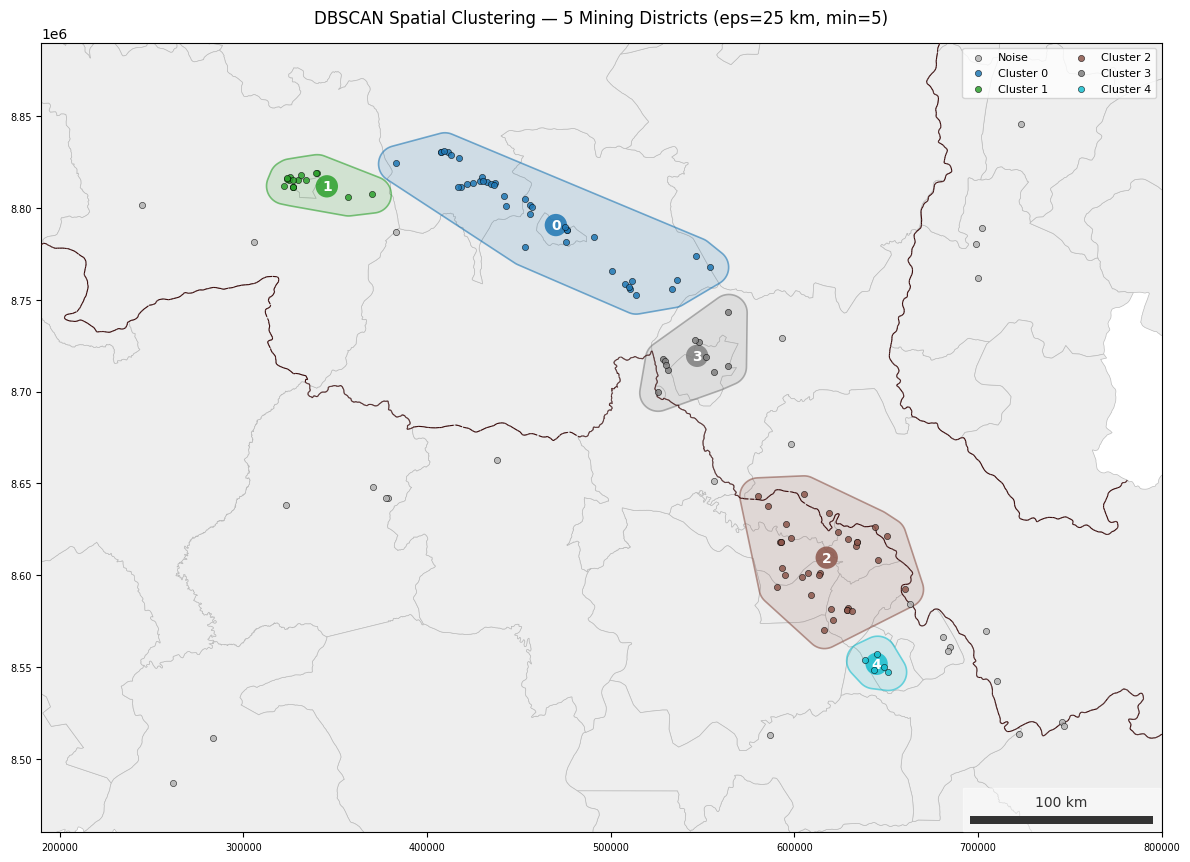

In [29]:
# Colour palette: one colour per cluster, grey for noise
n_c = n_clusters
palette = plt.cm.tab10(np.linspace(0, 1, max(n_c, 1)))
cluster_colors = {i: palette[i % len(palette)] for i in range(n_c)}
cluster_colors[-1] = (0.7, 0.7, 0.7, 0.5)   # noise → light grey

mrds_cluster["_color"] = mrds_cluster["cluster"].map(cluster_colors)

fig, ax = plt.subplots(figsize=(12, 10))

districts_utm.plot(ax=ax, color="#eeeeee", edgecolor="#bcbcbc", linewidth=0.5)
gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(CRS_PROJ).plot(
    ax=ax, color="#3B0B0B", linewidth=0.8, linestyle="--", zorder=3
)

# Cluster hulls (shaded footprint)
for idx, row in cluster_hulls.iterrows():
    c = cluster_colors.get(row["cluster"], (0.5, 0.5, 0.5, 0.3))
    gpd.GeoSeries([row.geometry], crs=CRS_PROJ).plot(
        ax=ax, color=mcolors.to_rgba(c, alpha=0.15),
        edgecolor=mcolors.to_rgba(c, alpha=0.6), linewidth=1.2
    )

# Mine points coloured by cluster
for cid, grp in mrds_cluster.groupby("cluster"):
    color = cluster_colors.get(cid, (0.7, 0.7, 0.7, 0.5))
    label = f"Cluster {cid}" if cid >= 0 else "Noise"
    gpd.GeoDataFrame(grp, geometry="geometry", crs=CRS_PROJ).plot(
        ax=ax, color=color, markersize=20, edgecolor="black",
        linewidth=0.4, alpha=0.85, zorder=5, label=label
    )

# Cluster centroids with ID label
for idx, row in cluster_hulls.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, str(row["cluster"]), fontsize=10, fontweight="bold",
            ha="center", va="center", color="white",
            bbox=dict(boxstyle="circle,pad=0.3", fc=cluster_colors.get(row["cluster"], "grey"),
                      ec="none", alpha=0.85))

ax.legend(loc="upper right", fontsize=8, frameon=True, ncol=2)
ax.set_title(
    f"DBSCAN Spatial Clustering — {n_clusters} Mining Districts (eps={EPS_M/1000:.0f} km, min={MIN_SAMPLES})",
    fontsize=12, pad=14
)
ax.axis("on")
ax.tick_params(labelsize=7)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

scalebar = ScaleBar(1, units="m", dimension="si-length", location="lower right",
                    fixed_value=100, fixed_units="km", frameon=True, color="#333333",
                    box_alpha=0.5, pad=0.5, scale_loc="top")
ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig(MAPS_OUT / "dbscan_clusters.png", dpi=300)
plt.show()

# Save clusters for downstream notebooks
mrds_cluster.to_file(DATA_PROCESSED / "mrds_clusters.gpkg", driver="GPKG")


## 2.6 Spatial autocorrelation — Moran's I

**Moran's I** tests whether the spatial distribution of mine counts across districts is random, clustered, or dispersed.

- **I > 0**: clustered (similar values near each other)
- **I ≈ 0**: random
- **I < 0**: dispersed

Using a **queen contiguity** spatial weights matrix (districts that share
any border or corner are considered neighbours).<br>

Library: **PySAL / esda**


In [30]:
# Build spatial weights from district geometries
w = Queen.from_dataframe(districts_counts, use_index=False)
w.transform = "r"   # row-standardise

y = districts_counts["mine_count"].values.astype(float)

moran = Moran(y, w)

print("=" * 45)
print(f"  Moran's I statistic : {moran.I:.4f}")
print(f"  Expected value (H₀) : {moran.EI:.4f}")
print(f"  p-value (sim.)      : {moran.p_sim:.4f}")
print(f"  Z-score             : {moran.z_sim:.2f}")
print()
if moran.p_sim < 0.05:
    direction = "positive" if moran.I > 0 else "negative"
    print(f"  → Statistically significant {direction} spatial autocorrelation")
    print(f"    (mine-rich districts tend to be near other mine-rich districts)")
else:
    print("  → No significant spatial autocorrelation detected (p ≥ 0.05)")
print("=" * 45)

  Moran's I statistic : 0.2053
  Expected value (H₀) : -0.0233
  p-value (sim.)      : 0.0140
  Z-score             : 2.55

  → Statistically significant positive spatial autocorrelation
    (mine-rich districts tend to be near other mine-rich districts)


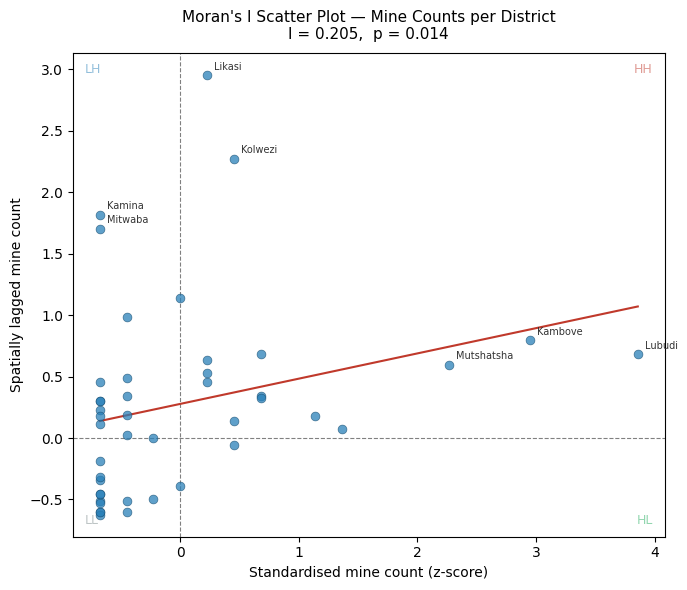

In [31]:
# Moran scatter plot
fig, ax = plt.subplots(figsize=(7, 6))

# Standardise
y_std = (y - y.mean()) / y.std()
lag_y = w.sparse.dot(y_std)          # spatially lagged values

ax.scatter(y_std, lag_y, c="#2980b9", edgecolors="#1a5276",
            linewidth=0.5, alpha=0.75, s=40, zorder=3)

# Add district name labels for outliers
threshold = 1.5
for i, (xs, yl) in enumerate(zip(y_std, lag_y)):
    if abs(xs) > threshold or abs(yl) > threshold:
        name = districts_counts.iloc[i]["NAME_2"]
        ax.annotate(name, (xs, yl), fontsize=7, xytext=(5, 4),
                    textcoords="offset points", color="#333")

# Reference lines
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")

# OLS trend line
m_coef = np.polyfit(y_std, lag_y, 1)
xs_line = np.linspace(y_std.min(), y_std.max(), 100)
ax.plot(xs_line, np.polyval(m_coef, xs_line), color="#c0392b", linewidth=1.5)

# Quadrant labels
ax.text( 0.98,  0.98, "HH", transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color="#c0392b", alpha=0.5)
ax.text( 0.02,  0.98, "LH", transform=ax.transAxes, ha="left",  va="top",
            fontsize=9, color="#2980b9", alpha=0.5)
ax.text( 0.98,  0.02, "HL", transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, color="#27ae60", alpha=0.5)
ax.text( 0.02,  0.02, "LL", transform=ax.transAxes, ha="left",  va="bottom",
            fontsize=9, color="#7f8c8d", alpha=0.5)

ax.set_xlabel("Standardised mine count (z-score)", fontsize=10)
ax.set_ylabel("Spatially lagged mine count", fontsize=10)
ax.set_title(
    f"Moran's I Scatter Plot — Mine Counts per District\nI = {moran.I:.3f},  p = {moran.p_sim:.3f}",
    fontsize=11, pad=10
)
plt.tight_layout()
plt.savefig(FIGURES_OUT / "morans_i_scatter.png", dpi=300)
plt.show()

## 2.7 Distance analysis

Proximity to infrastructure is a key determinant of mine viability. The **straight-line distance** is computed from each mine to:

- 1. The nearest primary/motorway road segment
- 2. The nearest river or stream
- 3. The international border (DRC–Zambia)

This produces a feature table that downstream notebooks can use for
regression or accessibility modelling.


In [32]:
from shapely.ops import unary_union  # noqa: E402

# --- Reference geometries (UTM)
primary_roads_union = unary_union(
    roads_utm[roads_utm["class"].isin(["motorway", "primary"])].geometry
)
water_union = unary_union(water_utm.geometry)
border_utm  = gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(CRS_PROJ).iloc[0]

# --- Distance computation (vectorised)
mrds_dist = mrds_utm.copy()
mrds_dist["dist_road_km"]   = mrds_dist.geometry.apply(
    lambda p: p.distance(primary_roads_union) / 1000
)
mrds_dist["dist_water_km"]  = mrds_dist.geometry.apply(
    lambda p: p.distance(water_union) / 1000
)
mrds_dist["dist_border_km"] = mrds_dist.geometry.apply(
    lambda p: p.distance(border_utm) / 1000
)

print("Distance statistics (km):")
print(
    mrds_dist[["dist_road_km", "dist_water_km", "dist_border_km"]]
    .describe()
    .round(1)
    .to_string()
)


Distance statistics (km):
       dist_road_km  dist_water_km  dist_border_km
count         132.0          132.0           132.0
mean          105.3            1.8            49.7
std            79.7            1.4            41.4
min             0.1            0.0             0.2
25%            17.7            0.8            23.9
50%           128.1            1.5            38.9
75%           183.4            2.8            68.7
max           243.4            8.2           223.3


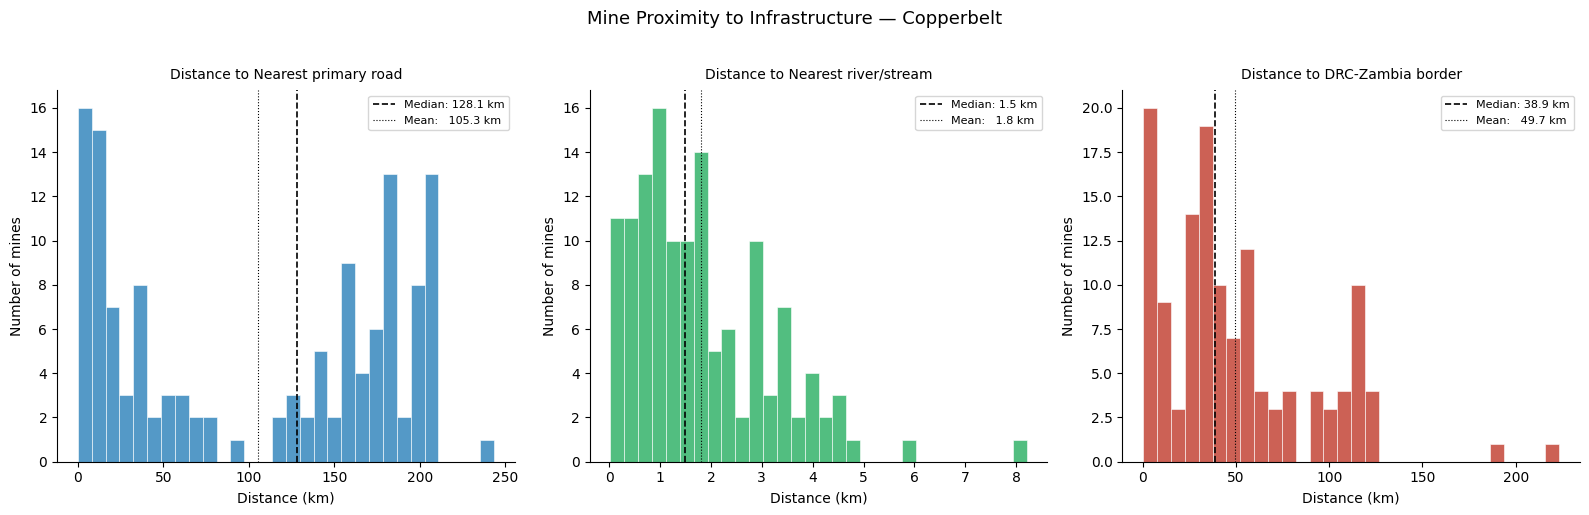

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

dist_cols  = ["dist_road_km",  "dist_water_km",  "dist_border_km"]
dist_labels = ["Nearest primary road",  "Nearest river/stream",  "DRC-Zambia border"]
colors      = ["#2980b9",              "#27ae60",               "#c0392b"]

for ax, col, lbl, clr in zip(axes, dist_cols, dist_labels, colors):
    data = mrds_dist[col].dropna()
    ax.hist(data, bins=30, color=clr, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.axvline(data.median(), color="black", linewidth=1.2, linestyle="--",
               label=f"Median: {data.median():.1f} km")
    ax.axvline(data.mean(),   color="black", linewidth=0.8, linestyle=":",
               label=f"Mean:   {data.mean():.1f} km")
    ax.set_xlabel("Distance (km)", fontsize=10)
    ax.set_ylabel("Number of mines", fontsize=10)
    ax.set_title(f"Distance to {lbl}", fontsize=10, pad=8)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Mine Proximity to Infrastructure — Copperbelt", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_OUT / "distance_histograms.png", dpi=300, bbox_inches="tight")
plt.show()


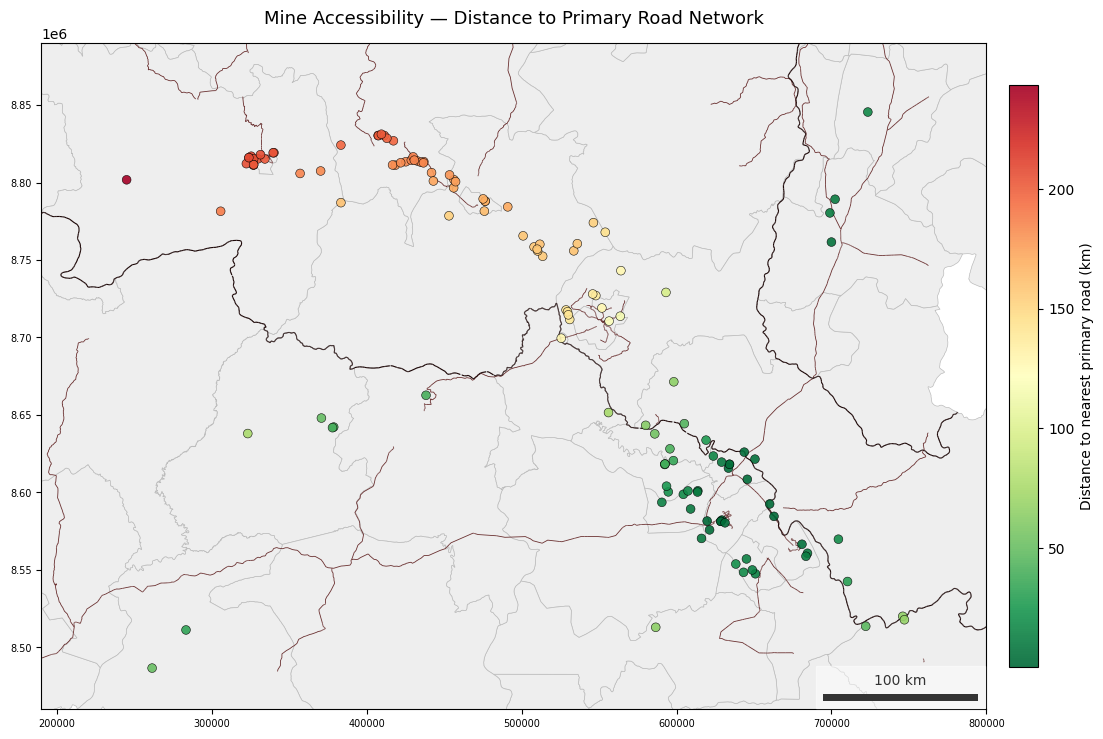


Saved to DATA_PROCESSED/mrds_features.gpkg


In [34]:
# --- Choropleth: distance to nearest road (per mine, mapped on study area)
fig, ax = plt.subplots(figsize=(12, 10))

districts_utm.plot(ax=ax, color="#eeeeee", edgecolor="#bcbcbc", linewidth=0.5)
gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(CRS_PROJ).plot(
    ax=ax, color="#1C0606", linewidth=0.8, linestyle="--", zorder=3
)

roads_utm.plot(
    ax=ax, edgecolor="#6A3030", linewidth=0.6, zorder=2
)

sc = ax.scatter(
    mrds_dist.geometry.x, mrds_dist.geometry.y,
    c=mrds_dist["dist_road_km"],
    cmap="RdYlGn_r",
    s=40, edgecolors="black", linewidth=0.4, alpha=0.9, zorder=5
)
plt.colorbar(sc, ax=ax, label="Distance to nearest primary road (km)",
             shrink=0.6, pad=0.02)

ax.set_title("Mine Accessibility — Distance to Primary Road Network", fontsize=13, pad=14)
ax.axis("on")
ax.tick_params(labelsize=7)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

scalebar = ScaleBar(1, units="m", dimension="si-length", location="lower right",
                    fixed_value=100, fixed_units="km", frameon=True, color="#333333",
                    box_alpha=0.5, pad=0.5, scale_loc="top")
ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig(MAPS_OUT / "distance_to_roads.png", dpi=300)
plt.show()

# Save feature table for notebook iv.analysis
mrds_dist[["site_name", "ore_map", "dist_road_km", "dist_water_km",
           "dist_border_km", "geometry"]].to_file(
    DATA_PROCESSED / "mrds_features.gpkg", driver="GPKG"
)

print("\nSaved to DATA_PROCESSED/mrds_features.gpkg")